In this experiment using the Food-101 dataset, my goal is to surpass the  accuracy reported in the [DeepFood paper](https://www.researchgate.net/publication/304163308_DeepFood_Deep_Learning-Based_Food_Image_Recognition_for_Computer-Aided_Dietary_Assessment), which achieved 77.4%. By leveraging modern deep learning techniques and architectures, I aim to improve upon their benchmark in food image recognition.





In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-ef356cb5-b33e-4506-8298-22807b1cb88d)


In [2]:
!wget https://raw.githubusercontent.com/snehilkumbhani/tensorflow/refs/heads/main/helper_functions.py

--2025-06-11 07:47:07--  https://raw.githubusercontent.com/snehilkumbhani/tensorflow/refs/heads/main/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17619 (17K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  17.21K  --.-KB/s    in 0.001s  

2025-06-11 07:47:08 (13.6 MB/s) - ‘helper_functions.py’ saved [17619/17619]



In [61]:
from helper_functions import create_tensorboard_callback,plot_loss_curves,compare_historys,unzip_data,load_and_prep_image

In [4]:
import tensorflow_datasets as tfds

In [5]:
datasets_list = tfds.list_builders()
print("food101" in datasets_list)

True


In [6]:

(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True,
                                             with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.VOJNU8_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.VOJNU8_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [7]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [8]:
class_names=ds_info.features["label"].names
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheesecake',
 'cheese_plate',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

To better understand the training data, let's examine a sample image from the Food-101 training dataset along with its corresponding label.

In [9]:
train_one_sample=train_data.take(1)

In [10]:
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [11]:
for image,label in train_one_sample:
  print(f"""
  Image shape:{image.shape}
  Image datatype:{image.dtype}
  Target class from Food101(tensor form):{label}
  Class name(str form):{class_names[label.numpy()]}
  """)


  Image shape:(512, 512, 3)
  Image datatype:<dtype: 'uint8'>
  Target class from Food101(tensor form):23
  Class name(str form):churros
  


In [12]:
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[189, 165, 121],
        [185, 161, 117],
        [181, 157, 113],
        ...,
        [111,  72,  33],
        [103,  64,  25],
        [ 94,  55,  16]],

       [[186, 162, 118],
        [183, 159, 115],
        [180, 156, 112],
        ...,
        [122,  83,  40],
        [113,  74,  31],
        [105,  66,  23]],

       [[180, 156, 112],
        [178, 154, 110],
        [177, 153, 109],
        ...,
        [132,  94,  45],
        [124,  87,  35],
        [120,  83,  31]],

       ...,

       [[207, 204, 159],
        [205, 201, 154],
        [204, 196, 147],
        ...,
        [231, 225, 191],
        [231, 225, 189],
        [231, 226, 188]],

       [[207, 204, 159],
        [205, 201, 154],
        [204, 196, 147],
        ...,
        [230, 224, 190],
        [230, 224, 188],
        [229, 223, 187]],

       [[206, 203, 158],
        [204, 200, 153],
        [203, 195, 146],
        ...,
        [229, 223, 18

In [13]:
import tensorflow as tf


In [14]:
tf.reduce_min(image),tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

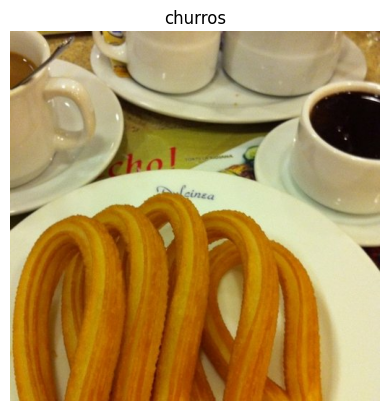

In [15]:
import matplotlib.pyplot as plt
plt.imshow(image)

plt.title(class_names[label.numpy()])

plt.axis(False)

In [16]:

def preprocess_img(image, label, img_shape=224):
  """
  Converts image datatype from 'uint8' -> 'float32' and reshapes
  image to [img_shape, img_shape, colour_channels]
  """
  image = tf.image.resize(image, [img_shape, img_shape])
  return tf.cast(image, tf.float32), label

\

In [17]:
preprocessed_img = preprocess_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2]}..., \nShape: {image.shape},\nDatatype: {image.dtype}\n")
print(f"Image after preprocessing:\n{preprocessed_img[:2]}...,\nShape: {preprocessed_img.shape},\nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[189 165 121]
  [185 161 117]
  [181 157 113]
  ...
  [111  72  33]
  [103  64  25]
  [ 94  55  16]]

 [[186 162 118]
  [183 159 115]
  [180 156 112]
  ...
  [122  83  40]
  [113  74  31]
  [105  66  23]]]..., 
Shape: (512, 512, 3),
Datatype: <dtype: 'uint8'>

Image after preprocessing:
[[[184.91327  160.91327  116.91326 ]
  [180.35715  156.35715  112.35714 ]
  [183.71428  160.71428  118.71429 ]
  ...
  [147.5915   108.66289   69.08129 ]
  [123.576454  84.576454  44.198887]
  [106.44359   67.44359   25.872158]]

 [[174.66837  150.66837  106.668365]
  [175.14285  151.14285  107.14286 ]
  [177.80103  153.22958  112.015305]
  ...
  [155.61722  119.545784  68.443695]
  [145.1989   108.19381   53.423363]
  [134.37747   98.30605   40.73462 ]]]...,
Shape: (224, 224, 3),
Datatype: <dtype: 'float32'>


In [18]:
train_data=train_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE)
train_data=train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)
test_data=test_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [19]:
train_data,test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [20]:
from helper_functions import create_tensorboard_callback

checkpoint_path = "model_checkpoint/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_acc",
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)


To accelerate training and improve memory efficiency, I will enable mixed precision training. This allows the model to use both 16-bit and 32-bit floating-point types during computation, which can speed up training on supported hardware (tesla T4) without compromising model accuracy.

In [21]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

In [22]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

I use EfficientNetB0 as the base model for feature extraction, with its pre-trained weights frozen initially to retain general image features.

In [23]:
from tensorflow.keras import layers

input_shape=(224,224,3)
base_model=tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable=False

inputs=layers.Input(shape=input_shape,name="input_layer")
x=base_model(inputs,training=False)
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dense(len(class_names))(x)
outputs=layers.Activation("softmax",dtype=tf.float32,name="softmax_float32")(x)
model0=tf.keras.Model(inputs,outputs)

model0.compile(loss="sparse_categorical_crossentropy",
               optimizer=tf.keras.optimizers.Adam(),
               metrics=["accuracy"]
               )

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
model0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 101)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
for layer in model0.layers:
  print(f"layer name:{layer.name} datatype:{layer.dtype} trainabel:{layer.trainable} dtype policy:{layer.dtype_policy}")

layer name:input_layer datatype:float32 trainabel:True dtype policy:<DTypePolicy "mixed_float16">
layer name:efficientnetb0 datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:global_average_pooling2d datatype:float32 trainabel:True dtype policy:<DTypePolicy "mixed_float16">
layer name:dense datatype:float32 trainabel:True dtype policy:<DTypePolicy "mixed_float16">
layer name:softmax_float32 datatype:float32 trainabel:True dtype policy:<DTypePolicy "float32">


In [26]:
for layer in model0.layers[1].layers:
    print(f"layer name:{layer.name} datatype:{layer.dtype} trainabel:{layer.trainable} dtype policy:{layer.dtype_policy}")

layer name:input_layer datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:rescaling datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:normalization datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:rescaling_1 datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:stem_conv_pad datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:stem_conv datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:stem_bn datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:stem_activation datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:block1a_dwconv datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer name:block1a_bn datatype:float32 trainabel:False dtype policy:<DTypePolicy "mixed_float16">
layer na

In [27]:
history1_fe_on_model0 = model0.fit(
    train_data,
    epochs=5,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[
        create_tensorboard_callback(
            dir_name="training_logs",
            experiment_name="efficientnetb0_101_classes_all_data_feature_extract"
        ),
        model_checkpoint
    ]
)


Saving TensorBoard log files to: training_logs/efficientnetb0_101_classes_all_data_feature_extract/20250611-075958
Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 209s 76ms/step - accuracy: 0.4758 - loss: 2.2798 - val_accuracy: 0.6952 - val_loss: 1.1373
Epoch 2/5


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_acc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 198s 81ms/step - accuracy: 0.6666 - loss: 1.2884 - val_accuracy: 0.7153 - val_loss: 1.0400
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 205s 82ms/step - accuracy: 0.7034 - loss: 1.1335 - val_accuracy: 0.7222 - val_loss: 1.0011
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 169s 68ms/step - accuracy: 0.7252 - loss: 1.0391 - val_accuracy: 0.7333 - val_loss: 0.9786
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 203s 69ms/step - accuracy: 0.7408 - loss: 0.9815 - val_accuracy: 0.7325 - val_loss: 0.9701


In [28]:
results1_fe_on_model0=model0.evaluate(test_data)
results1_fe_on_model0

790/790 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.7296 - loss: 0.9803


[0.976874589920044, 0.7338613867759705]

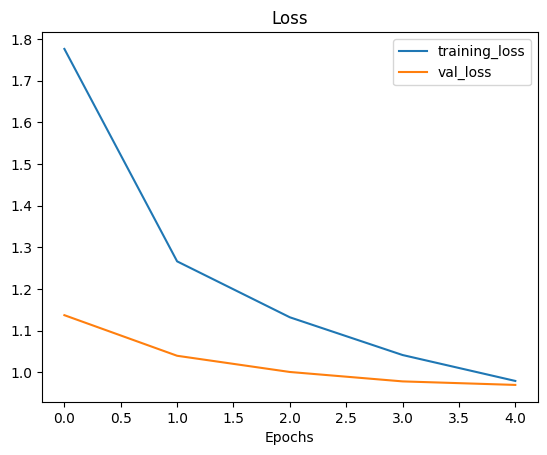

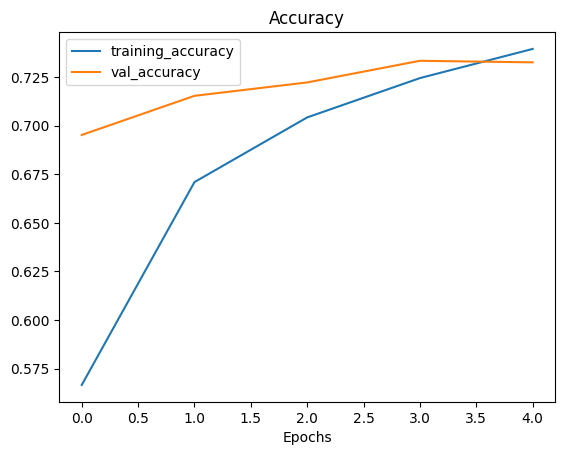

In [34]:
plot_loss_curves(history1_fe_on_model0)

Fine-tuning allows the model to shift from general visual features learned on ImageNet to more task-specific patterns in food images, often resulting in improved accuracy.

In [41]:
base_model.trainable=True

for layer in base_model.layers[:-5]:
  layer.trainable=False

In [42]:
model0.compile(loss="sparse_categorical_crossentropy",
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
               metrics=["accuracy"])


In [43]:
for layer in model0.layers:
  print(layer.name,layer.trainable)

input_layer True
efficientnetb0 True
global_average_pooling2d True
dense True
softmax_float32 True


In [44]:
for layer_number,layer in enumerate(base_model.layers):
  print(layer_number,layer.name,layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [45]:
fine_tune_epochs=10

history1_fe_on_model0_fine_tune=model0.fit(train_data,
                                          epochs=fine_tune_epochs,
                                          validation_data=test_data,
                                          validation_steps=int(0.15*len(test_data)),
                                          initial_epoch= history1_fe_on_model0.epoch[-1],
                                          callbacks=[ create_tensorboard_callback(
                                                    dir_name="training_logs",
                                                    experiment_name="efficientnetb0_101_classes_all_data_feature_extract"
                                                    ),
                                          model_checkpoint])

Saving TensorBoard log files to: training_logs/efficientnetb0_101_classes_all_data_feature_extract/20250611-082509
Epoch 5/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 197s 72ms/step - accuracy: 0.7391 - loss: 0.9823 - val_accuracy: 0.7489 - val_loss: 0.9100
Epoch 6/10


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_acc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 170s 64ms/step - accuracy: 0.7828 - loss: 0.8236 - val_accuracy: 0.7579 - val_loss: 0.8815
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 210s 67ms/step - accuracy: 0.8043 - loss: 0.7352 - val_accuracy: 0.7561 - val_loss: 0.8720
Epoch 8/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 201s 84ms/step - accuracy: 0.8251 - loss: 0.6691 - val_accuracy: 0.7659 - val_loss: 0.8446
Epoch 9/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 203s 85ms/step - accuracy: 0.8387 - loss: 0.6116 - val_accuracy: 0.7659 - val_loss: 0.8485
Epoch 10/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 211s 64ms/step - accuracy: 0.8490 - loss: 0.5669 - val_accuracy: 0.7667 - val_loss: 0.8452


The model achieved a training accuracy of 84.90%, surpassing the target accuracy set by the DeepFood paper.



In [48]:
results1_fe_on_model0=model0.evaluate(test_data)
results1_fe_on_model0

790/790 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.7647 - loss: 0.8482


[0.843970537185669, 0.7672871351242065]

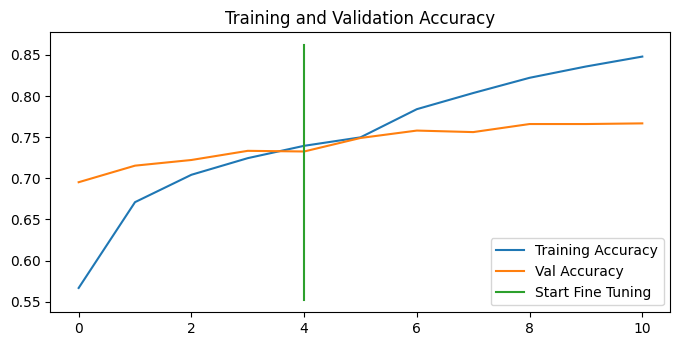

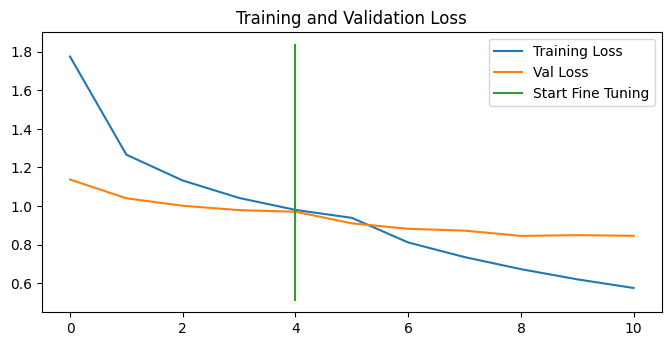

In [47]:
compare_historys(history1_fe_on_model0,history1_fe_on_model0_fine_tune,initial_epochs=5)

Next, I evaluate the trained model on a few randomly selected food images to visually inspect its predictions. This helps verify how well the model generalizes to individual samples and provides qualitative insights into its performance.

In [49]:
preds_probs=model0.predict(test_data,verbose=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step


In [50]:
pred_classes=preds_probs.argmax(axis=1)

pred_classes[:10]

array([37, 94, 29, 40, 60, 13, 96,  2, 21, 25])

In [51]:
ylabels=[]
for images,labels in test_data.unbatch():
  ylabels.append(labels.numpy().argmax())
  ylabels[:10]

In [64]:

!wget https://github.com/snehilkumbhani/tensorflow/blob/main/custom_food_images.zip

unzip_data("custom_food_images.zip")

--2025-06-11 09:31:44--  https://github.com/snehilkumbhani/tensorflow/blob/main/custom_food_images.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘custom_food_images.zip.2’

custom_food_images.     [ <=>                ] 174.75K  --.-KB/s    in 0.02s   

2025-06-11 09:31:44 (7.87 MB/s) - ‘custom_food_images.zip.2’ saved [178948]



In [65]:
custom_food_images = ["custom_food_images/" + img_path for img_path in os.listdir("custom_food_images")]
custom_food_images

['custom_food_images/sushi.jpeg',
 'custom_food_images/chicken_wings.jpeg',
 'custom_food_images/ramen.jpeg',
 'custom_food_images/hamburger.jpeg',
 'custom_food_images/steak.jpeg',
 'custom_food_images/pizza-dad.jpeg']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


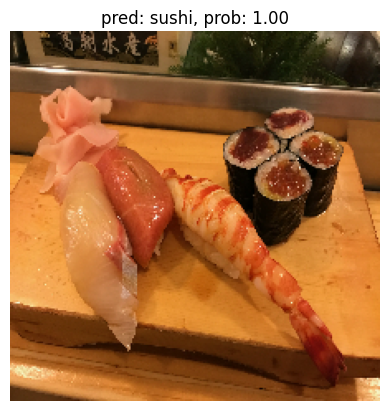

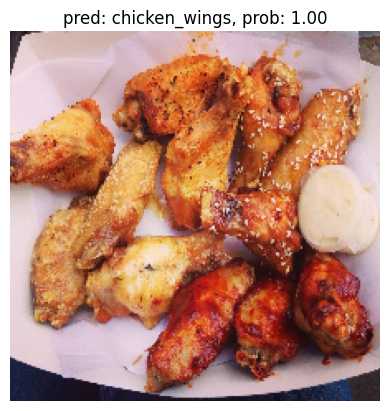

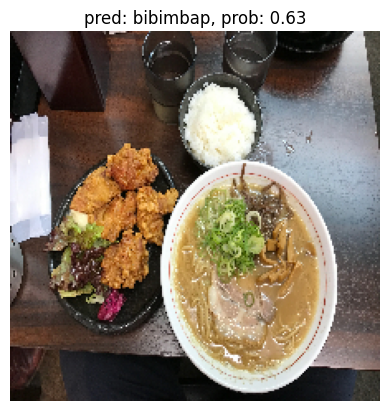

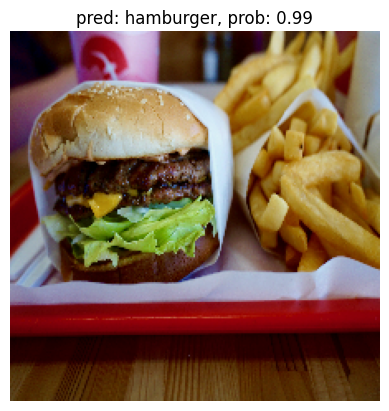

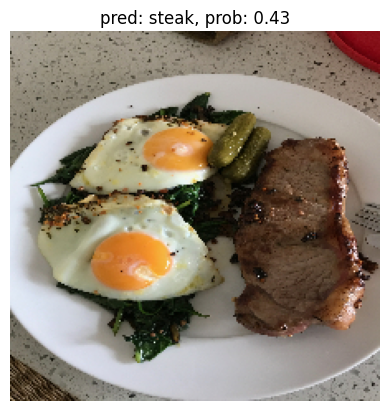

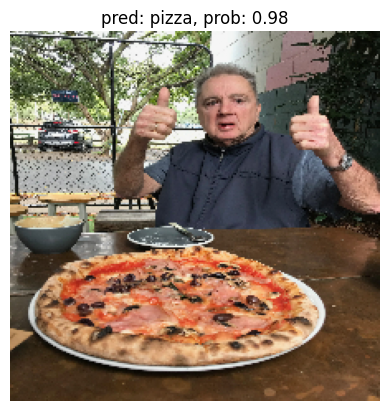

In [66]:
for img in custom_food_images:
  img = load_and_prep_image(img, scale=False)
  pred_prob = model0.predict(tf.expand_dims(img, axis=0))
  pred_class = class_names[pred_prob.argmax()]
  plt.figure()
  plt.imshow(img/255.)
  plt.title(f"pred: {pred_class}, prob: {pred_prob.max():.2f}")
  plt.axis(False)

Out of the 6 randomly selected test images, the model correctly classified 5, misclassifying only the image of ramen. This results in an accuracy of 83.33% on this small sample, indicating that the model performs well on diverse food categories, though some dishes with visually similar elements may still pose challenges.

